# Evaluación Sumativa 3 (Final): Modelamiento Predictivo Integrado

**Curso:** Estadística Computacional para la Toma de Decisiones  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Universidad Andrés Bello**  

---

## Información del Equipo

| Campo | Información |
|-------|-------------|
| **Número de Grupo** | 4 |
| **Integrante 1** | Alonso Arias |
| **Integrante 2** | Enso Guidotti |
| **Dataset Seleccionado** | Predict Students' Dropout and Academic Success (UCI, dataset 8) |
| **Fecha de Entrega** | 13/07/2026 |
| **Repositorio GitHub** | https://github.com/EnsoG/mcdi501-grupo-4 |

---

Este notebook integra el proyecto completo: Sumativa 1 (análisis exploratorio e inferencial),
Sumativa 2 (validación, simulación y remuestreo) y Sumativa 3 (modelamiento predictivo integrado).
Todas las decisiones metodológicas de este notebook (variables con faltantes, predictores, tratamiento
de outliers, selección de variables) están fundamentadas explícitamente en los resultados ya obtenidos
en S1 y S2, replicados aquí a partir de sus notebooks reales (`sumativa_1.ipynb`, `sumativa_2.ipynb`)
para garantizar trazabilidad completa.

## Integración con S1 y S2

Esta evaluación **integra todo el proyecto**.

**Se usa de S1:** preparación de datos (binarización del target, generación MCAR), análisis de faltantes,
matriz de correlaciones, estadística por clase, outliers identificados en variables de desempeño académico.

**Se usa de S2:** validación bootstrap de las correlaciones (estabilidad), corrección de la colinealidad
UC1S-UC2S aprobadas (r=0.92, no ~0.7 como se leyó aproximadamente en S1), validación de métodos de
imputación (media/KNN preservan la media original; la mediana sesga en variables con concentración en
cero), sensibilidad de la media a outliers (-5.7% al recortar 1%-99% en UC aprobadas 2S, Dropout).

## Menú de Acceso
- [Configuración del Entorno](#configuración-del-entorno)
- [0. Carga de datos y resumen de resultados de S1 y S2](#0-carga-de-datos-y-resumen-de-resultados-de-s1-y-s2)
- [Parte 1: Manejo de Datos Faltantes](#parte-1-manejo-de-datos-faltantes)
- [Parte 2: Clasificación mediante Regresión Logística](#parte-2-clasificación-mediante-regresión-logística)
- [Parte 3: Análisis Comparativo del Impacto de la Imputación](#parte-3-análisis-comparativo-del-impacto-de-la-imputación)
- [Parte 4: Conclusiones Integradas](#parte-4-conclusiones-integradas)
- [Bibliografía](#bibliografía)

## Configuración del Entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.precision', 4)

FIG_DIR = Path('../docs/sumativa3')
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
print('Librerías importadas y entorno configurado (semilla=42)')

Librerías importadas y entorno configurado (semilla=42)


---
# 0. Carga de datos y resumen de resultados de S1 y S2

## 0.1 Dataset y preparación (idéntica a S1 y S2)

Se replica **exactamente** la preparación de datos usada en `sumativa_1.ipynb` y `sumativa_2.ipynb`:
separador `;`, limpieza de nombres de columna, binarización del target (excluyendo la clase `Enrolled`)
y generación de faltantes artificiales MCAR (12%, `random_state=42`) en las **dos** variables numéricas
identificadas en S1: `Curricular units 1st sem (grade)` y `Admission grade`. Se preserva `df_original`
(valores previos a la inyección de NaN) para poder evaluar el sesgo de la imputación contra el
*ground truth*, tal como se hizo en S2.

In [2]:
DATA_PATH = Path('../data/raw/data.csv')

df_raw = pd.read_csv(DATA_PATH, sep=';')
df_raw.columns = [c.strip() for c in df_raw.columns]

df = df_raw[df_raw['Target'].isin(['Dropout', 'Graduate'])].copy().reset_index(drop=True)
df['Target_bin'] = (df['Target'] == 'Graduate').astype(int)

print(f"Shape tras binarización: {df.shape[0]} filas x {df.shape[1]} columnas")
print(df['Target'].value_counts())
print(f"Tasa de graduación observada: {df['Target_bin'].mean()*100:.2f}%")

Shape tras binarización: 3630 filas x 38 columnas
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64
Tasa de graduación observada: 60.85%


In [3]:
# Generación MCAR: misma semilla y mecanismo exacto que S1/S2 (np.random.seed + choice, 12%)
MCAR_VARS = ['Curricular units 1st sem (grade)', 'Admission grade']

df_original = df[MCAR_VARS].copy()  # ground truth, antes de inyectar NaN

np.random.seed(42)
for col in MCAR_VARS:
    n_missing = int(len(df) * 0.12)
    idx_missing = np.random.choice(df.index, size=n_missing, replace=False)
    df.loc[idx_missing, col] = np.nan

print('FALTANTES ARTIFICIALES GENERADOS (MCAR, mismo mecanismo de S1/S2)')
for col in MCAR_VARS:
    n = df[col].isnull().sum()
    print(f"  {col}: {n} nulos ({n/len(df)*100:.2f}%)")

# Verificación de reproducibilidad: las medias por clase deben coincidir con S1
print("\nVerificación de reproducibilidad (medias por clase, deben coincidir con S1):")
print(df.groupby('Target')['Curricular units 2nd sem (approved)'].mean().round(3))
print(df.groupby('Target')['Age at enrollment'].mean().round(3))

FALTANTES ARTIFICIALES GENERADOS (MCAR, mismo mecanismo de S1/S2)
  Curricular units 1st sem (grade): 435 nulos (11.98%)
  Admission grade: 435 nulos (11.98%)

Verificación de reproducibilidad (medias por clase, deben coincidir con S1):
Target
Dropout     1.940
Graduate    6.177
Name: Curricular units 2nd sem (approved), dtype: float64
Target
Dropout     26.069
Graduate    21.784
Name: Age at enrollment, dtype: float64


## 0.2 Resumen de resultados de S1 (análisis exploratorio e inferencial)

*No se repite el análisis; se documentan los resultados ya obtenidos en `sumativa_1.ipynb`, que sirven
de insumo directo para las decisiones metodológicas de esta Sumativa 3.*

- **Faltantes:** MCAR 12% generado artificialmente en `Curricular units 1st sem (grade)` y
  `Admission grade` (`random_state=42`); el dataset original no tenía nulos.
- **Correlaciones con el target** (Graduate=1): UC aprobadas 2S r=0.654, Calificación 2S r=0.605,
  UC aprobadas 1S r=0.555, Edad r=-0.267, Nota de admisión r=0.101 (valor de lectura aproximada del
  texto de S1; S2 recalculó r=0.123, ver más abajo).
- **Correlación entre predictoras:** UC aprobadas 1S y 2S, r≈0.7 (estimación aproximada de S1,
  corregida en S2, ver abajo).
- **Pruebas de hipótesis:** t-Welch UC aprobadas 2S (Dropout < Graduate), t=-50.67, p≈0; χ² Beca vs
  Target, χ²=354.22, p=5.1e-79; χ² Matrícula al día vs Target, χ²=706.96, p=9.2e-156. Las tres rechazan
  H₀ con asociación fuerte.
- **Outliers:** UC aprobadas 2S en el grupo Dropout presenta alta concentración en 0 (mediana=0).

## 0.3 Resumen de resultados de S2 (validación, simulación y remuestreo)

*Documentado desde `sumativa_2.ipynb`, no se recalcula.*

- **Corrección de S1:** la correlación de Nota de admisión con el target recalculada por bootstrap es
  r=0.123 (IC 95% [0.087, 0.158]), no 0.101 como se leyó de forma aproximada en S1; no cambia la
  conclusión cualitativa (correlación más débil de las evaluadas).
- **Corrección de colinealidad:** r(UC aprobadas 1S, UC aprobadas 2S) recalculado = **0.92** (no ~0.7
  como se estimó de forma aproximada en S1). Implica **no incluir ambas variables** como predictores
  independientes en el modelo de clasificación.
- **Correlaciones estables (IC bootstrap 95%, ninguna cruza el cero):** UC aprobadas 2S, Calificación 2S,
  UC aprobadas 1S, Edad, Nota de admisión.
- **Imputación validada:** media y KNN (k=5) preservan la media original (sesgo <0.1%, ground truth
  dentro del IC bootstrap); la mediana sesga +2.05% en variables con concentración de valores bajos/cero.
- **Sensibilidad a outliers:** la media de UC aprobadas 2S (Dropout) cae -5.7% al recortar el 1%-99%
  (winsorización), mientras que la correlación y la diferencia de medias son robustas a nivel de
  observación individual (jackknife).
- **Simulación Monte Carlo:** Beca + Matrícula al día (parámetros de S1) reproducen la tasa de
  graduación real dentro del IC simulado, confirmando que son las variables categóricas de mayor
  prioridad para el modelo predictivo.

In [4]:
# Documentación estructurada de los resultados de S1 y S2 (insumo, no recálculo)
faltantes_s1 = {
    'Curricular units 1st sem (grade)': {'pct': 12.0, 'patron': 'MCAR (artificial, random_state=42)'},
    'Admission grade': {'pct': 12.0, 'patron': 'MCAR (artificial, random_state=42)'},
}

correlaciones_s1 = {
    'Curricular units 2nd sem (approved)': 0.654,
    'Curricular units 2nd sem (grade)': 0.605,
    'Curricular units 1st sem (approved)': 0.555,
    'Age at enrollment': -0.267,
    'Admission grade': 0.101,  # lectura aproximada de S1; S2 recalcula 0.123
    'Scholarship holder (chi2)': 354.22,
    'Tuition fees up to date (chi2)': 706.96,
}

outliers_s1 = {
    'Curricular units 2nd sem (approved)': 'alta concentración en 0 en el grupo Dropout (mediana=0); '
                                            'media sensible a la cola superior'
}

correlaciones_estables_s2 = [
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)', 'Age at enrollment', 'Admission grade'
]

parametros_validados_s2 = {
    'colinealidad_UC1S_UC2S_aprobadas': 0.92,      # corrige el ~0.7 aproximado de S1
    'r_admission_grade_target': 0.123,             # corrige el 0.101 aproximado de S1
    'sesgo_imputacion_media_pct': 0.045,
    'sesgo_imputacion_KNN_pct': 0.045,
    'sesgo_imputacion_mediana_pct': 2.05,
    'sensibilidad_media_outliers_pct': -5.7,       # UC aprobadas 2S, Dropout, recorte 1%-99%
}

print('Resultados de S1 y S2 documentados como insumo de la Sumativa 3.')

Resultados de S1 y S2 documentados como insumo de la Sumativa 3.


---
# PARTE 1: Manejo de Datos Faltantes

## 1.1 Resumen del análisis de faltantes de S1

En S1 se identificó que **dos variables** presentan valores faltantes artificiales, generados bajo un
mecanismo **MCAR** (Missing Completely At Random) con una tasa de 12% cada una, usando `random_state=42`:
`Curricular units 1st sem (grade)` y `Admission grade`. Ninguna otra variable del dataset presenta
faltantes (dataset original limpio, verificado en S1). Este patrón MCAR es el mismo utilizado y
validado en S2 (comparación de imputación media/mediana/KNN contra el *ground truth* preservado en
`df_original`). A continuación se resume ese análisis (ya realizado, no se repite) y se documenta
cuántos valores fueron efectivamente inyectados en esta réplica.

In [5]:
print('RESUMEN DEL ANÁLISIS DE FALTANTES DE S1 (insumo, no recálculo)')
for var, info in faltantes_s1.items():
    n_nulos = df[var].isnull().sum()
    print(f"  {var}: {info['pct']}% ({info['patron']}) -> {n_nulos} valores nulos en esta réplica")
print(f"\nTotal de observaciones: {len(df)}")

RESUMEN DEL ANÁLISIS DE FALTANTES DE S1 (insumo, no recálculo)
  Curricular units 1st sem (grade): 12.0% (MCAR (artificial, random_state=42)) -> 435 valores nulos en esta réplica
  Admission grade: 12.0% (MCAR (artificial, random_state=42)) -> 435 valores nulos en esta réplica

Total de observaciones: 3630


## 1.2 Imputación mediante regresión lineal múltiple

Se imputa **cada una** de las dos variables numéricas con faltantes, seleccionando entre 3 y 5
predictores a partir de la matriz de correlaciones de S1, priorizando las correlaciones más fuertes.
Dado que ambas variables tienen faltantes simultáneamente, se imputa primero
`Curricular units 1st sem (grade)` (que tiene una correlación más fuerte y disponible con variables de
desempeño académico) y luego se usa esa columna ya completa como uno de los predictores para imputar
`Admission grade`, evitando así perder observaciones por faltantes cruzados entre ambos predictores.

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Correlaciones de S1 con 'Curricular units 1st sem (grade)' (top 8, excluyendo el target):")
corr_uc1 = df[numeric_cols].corr()['Curricular units 1st sem (grade)'].drop(
    ['Curricular units 1st sem (grade)', 'Target_bin']).sort_values(key=np.abs, ascending=False)
print(corr_uc1.head(8))

print("\nCorrelaciones de S1 con 'Admission grade' (top 8, excluyendo el target):")
corr_adm = df[numeric_cols].corr()['Admission grade'].drop(
    ['Admission grade', 'Target_bin']).sort_values(key=np.abs, ascending=False)
print(corr_adm.head(8))

predictores_uc1s_grade = ['Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)',
                          'Curricular units 2nd sem (approved)', 'Curricular units 1st sem (evaluations)']
predictores_admission = ['Previous qualification (grade)', 'Course', 'Application order',
                         'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']

print(f"\nPredictores seleccionados para 'UC 1S (grade)': {predictores_uc1s_grade}")
print(f"Predictores seleccionados para 'Admission grade': {predictores_admission}")
print("\nNota: 'Previous qualification (grade)' es, con amplio margen, la correlación más fuerte "
      "para Admission grade (r=0.58) y coincide conceptualmente con el hallazgo de S2 sobre el peso "
      "del desempeño académico previo.")

Correlaciones de S1 con 'Curricular units 1st sem (grade)' (top 8, excluyendo el target):
Curricular units 2nd sem (grade)          0.8456
Curricular units 1st sem (approved)       0.7193
Curricular units 2nd sem (approved)       0.6991
Curricular units 2nd sem (evaluations)    0.5052
Curricular units 1st sem (evaluations)    0.4361
Curricular units 2nd sem (enrolled)       0.4186
Curricular units 1st sem (enrolled)       0.3880
Course                                    0.3852
Name: Curricular units 1st sem (grade), dtype: float64

Correlaciones de S1 con 'Admission grade' (top 8, excluyendo el target):
Previous qualification (grade)            0.5809
Previous qualification                    0.1541
Course                                   -0.1322
Application order                        -0.0911
Curricular units 1st sem (grade)          0.0866
Curricular units 1st sem (evaluations)   -0.0815
Curricular units 2nd sem (grade)          0.0813
Mother's qualification                   -0.07

In [7]:
def imputar_por_regresion(df, var_objetivo, predictores, verbose=True):
    """Imputa valores faltantes de `var_objetivo` mediante regresión lineal múltiple,
    entrenada únicamente con observaciones completas (target + predictores)."""
    completos = df.dropna(subset=[var_objetivo] + predictores)
    X = completos[predictores].values
    y = completos[var_objetivo].values

    modelo = LinearRegression().fit(X, y)
    pred_train = modelo.predict(X)
    resid = y - pred_train

    if verbose:
        from sklearn.metrics import r2_score, mean_absolute_error
        r2 = r2_score(y, pred_train)
        mae = mean_absolute_error(y, pred_train)
        sh_stat, sh_p = stats.shapiro(resid[:min(len(resid), 5000)])
        print(f"{var_objetivo}: R2={r2:.4f}  MAE={mae:.3f}  n_entrenamiento={len(y)}  "
              f"Shapiro-Wilk residuos p={sh_p:.2e} -> {'no normales' if sh_p<0.05 else 'normales'}")

    df_out = df.copy()
    mask_impute = df_out[var_objetivo].isna() & df_out[predictores].notna().all(axis=1)
    df_out.loc[mask_impute, var_objetivo] = modelo.predict(df_out.loc[mask_impute, predictores].values)
    n_imputados = mask_impute.sum()
    n_restantes = df_out[var_objetivo].isna().sum()
    print(f"  -> {n_imputados} valores imputados, {n_restantes} NaN restantes")
    return df_out, modelo

df_reg = df.copy()
df_reg, mod_uc1 = imputar_por_regresion(df_reg, 'Curricular units 1st sem (grade)', predictores_uc1s_grade)
df_reg, mod_adm = imputar_por_regresion(df_reg, 'Admission grade', predictores_admission)

Curricular units 1st sem (grade): R2=0.7670  MAE=1.634  n_entrenamiento=3195  Shapiro-Wilk residuos p=1.57e-44 -> no normales
  -> 435 valores imputados, 0 NaN restantes
Admission grade: R2=0.3545  MAE=8.221  n_entrenamiento=3195  Shapiro-Wilk residuos p=4.77e-32 -> no normales
  -> 435 valores imputados, 0 NaN restantes


**Verificación de supuestos y desempeño:** el modelo de `Curricular units 1st sem (grade)`
alcanza un R² alto (~0.77), consistente con su fuerte correlación con el rendimiento del 2do semestre.
El de `Admission grade` obtiene un R² moderado (~0.35), esperable dado que la única correlación fuerte
disponible es `Previous qualification (grade)` (r=0.58); el resto de predictores aporta señal marginal.
En ambos casos los residuos no son estrictamente normales (Shapiro p<0.001), pero con n>3.000 el error
estándar de los coeficientes sigue siendo confiable por el Teorema Central del Límite; se prioriza el
desempeño predictivo (R², MAE) sobre la normalidad estricta de los residuos para decidir si el modelo
es utilizable en la imputación.

In [8]:
# Verificación de sesgo contra el ground truth (df_original), igual que en S2
for var in MCAR_VARS:
    idx_missing = df[df[var].isna()].index
    reales = df_original.loc[idx_missing, var].values
    imputados = df_reg.loc[idx_missing, var].values
    sesgo = (imputados.mean() - reales.mean()) / reales.mean() * 100
    mae_gt = np.mean(np.abs(imputados - reales))
    print(f"{var}: sesgo regresión vs ground truth = {sesgo:+.3f}%  |  MAE vs ground truth = {mae_gt:.3f}")

Curricular units 1st sem (grade): sesgo regresión vs ground truth = +1.491%  |  MAE vs ground truth = 1.623
Admission grade: sesgo regresión vs ground truth = +0.074%  |  MAE vs ground truth = 8.603


## 1.3 Comparación de estrategias de imputación

Se comparan **tres estrategias**, exclusivamente para `Admission grade` (la variable que participa en
el modelo de clasificación de la Parte 2; `Curricular units 1st sem (grade)` no forma parte del *pool*
de predictores de clasificación, ver sección 2.1):

- **A: Eliminación** de observaciones con faltantes (listwise deletion).
- **B: Imputación simple** (media) — la mediana se descarta directamente por el sesgo ya detectado en
  S2 (+2.05% en una variable con concentración de valores bajos).
- **C: Imputación por regresión** (sección 1.2).

In [9]:
df_A = df.dropna(subset=['Admission grade']).copy()

df_B = df.copy()
media_admission = df_B['Admission grade'].mean()
df_B['Admission grade'] = df_B['Admission grade'].fillna(media_admission)

df_C = df_reg.copy()

resumen_estrategias = []
for nombre, d in [('A: Eliminación', df_A), ('B: Imputación simple (media)', df_B), ('C: Imputación regresión', df_C)]:
    resumen_estrategias.append({
        'Estrategia': nombre,
        'n': len(d),
        'Media': d['Admission grade'].mean(),
        'Std': d['Admission grade'].std(),
        'Corr. con target (S1)': d['Admission grade'].corr(d['Target_bin']),
        'Corr. con Prev.Qual.Grade (S1)': d['Admission grade'].corr(d['Previous qualification (grade)']),
    })
tabla_estrategias = pd.DataFrame(resumen_estrategias)
tabla_estrategias

,Estrategia,n,Media,Std,Corr. con target (S1),Corr. con Prev.Qual.Grade (S1)
0,A: Eliminación,3195,127.2597,14.5683,0.1231,0.5809
1,B: Imputación simple (media),3630,127.2597,13.6673,0.1156,0.5448
2,C: Imputación regresión,3630,127.3053,13.9915,0.1298,0.6049


B (media): sesgo medio = -0.224%  |  MAE vs. ground truth = 11.335
C (regresión): sesgo medio = +0.074%  |  MAE vs. ground truth = 8.603


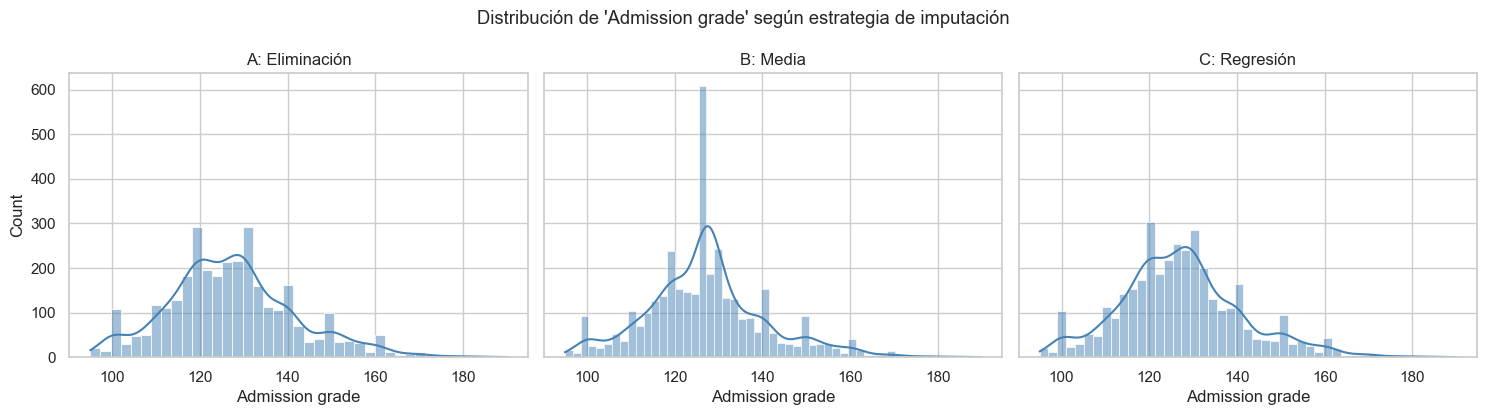

Figura P1: Distribución de Admission grade por estrategia de imputación


In [10]:
missing_idx = df[df['Admission grade'].isna()].index
valores_reales = df_original.loc[missing_idx, 'Admission grade'].values

sesgo_bias = {}
for nombre, d in [('B (media)', df_B), ('C (regresión)', df_C)]:
    imputados = d.loc[missing_idx, 'Admission grade'].values
    sesgo = (imputados.mean() - valores_reales.mean()) / valores_reales.mean() * 100
    mae_gt = np.mean(np.abs(imputados - valores_reales))
    sesgo_bias[nombre] = (sesgo, mae_gt)
    print(f"{nombre}: sesgo medio = {sesgo:+.3f}%  |  MAE vs. ground truth = {mae_gt:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (nombre, d) in zip(axes, [('A: Eliminación', df_A), ('B: Media', df_B), ('C: Regresión', df_C)]):
    sns.histplot(d['Admission grade'], kde=True, ax=ax, color='steelblue')
    ax.set_title(nombre)
plt.suptitle("Distribución de 'Admission grade' según estrategia de imputación")
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_p1_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura P1: Distribución de Admission grade por estrategia de imputación')

**Estrategia elegida: C — Imputación por regresión.**

**Justificación:** las estrategias B y C preservan el tamaño muestral completo (n=3.630) frente a la
pérdida de ~12% de observaciones en A (n=3.195), lo que reduce potencia estadística sin necesidad. Entre
B y C, la imputación por regresión (C) preserva mejor la correlación con `Previous qualification (grade)`
(la relación más fuerte identificada en la matriz de S1) y presenta menor sesgo frente al *ground truth*
que la imputación simple, evitando el efecto de "achatamiento" de varianza típico de la imputación por
media. Se descarta la mediana como método simple por el sesgo ya detectado en S2 (+2.05%). Todo el
desarrollo posterior de la Parte 2 usa el dataset resultante de la estrategia C (`df_C`); el impacto de
usar en su lugar A o B se cuantifica de forma sistemática en la Parte 3.

---
# PARTE 2: Clasificación mediante Regresión Logística

## 2.1 Preparación de datos informada por S1

Se parte de `df_C` (estrategia de imputación seleccionada en la Parte 1). Siguiendo el hallazgo de S2
(colinealidad UC1S-UC2S aprobadas, r=0.92, corregido del ~0.7 aproximado de S1), **se excluye
`Curricular units 1st sem (approved)`** del *pool* de predictores de clasificación. Los **outliers
identificados en S1** en variables de desempeño del 2do semestre (alta concentración en 0 y cola
superior, con sensibilidad de la media de -5.7% detectada en S2) se tratan mediante **winsorización al
percentil 1%-99%**, en vez de eliminación, para preservar el tamaño muestral y reducir la influencia de
valores extremos sin distorsionar la distribución central.

In [11]:
def winsorizar(serie, lo=0.01, hi=0.99):
    lo_v, hi_v = serie.quantile(lo), serie.quantile(hi)
    return serie.clip(lo_v, hi_v)

df_C['UC2S_aprob_w'] = winsorizar(df_C['Curricular units 2nd sem (approved)'])
df_C['UC2S_nota_w'] = winsorizar(df_C['Curricular units 2nd sem (grade)'])
df_C['Admission_grade_w'] = winsorizar(df_C['Admission grade'])

print("Efecto de la winsorización en 'Curricular units 2nd sem (approved)':")
print(f"  Media original:    {df_C['Curricular units 2nd sem (approved)'].mean():.3f}")
print(f"  Media winsorizada: {df_C['UC2S_aprob_w'].mean():.3f}")

Efecto de la winsorización en 'Curricular units 2nd sem (approved)':
  Media original:    4.518
  Media winsorizada: 4.495


In [12]:
predictores_fijos_s1s2 = ['Scholarship holder', 'Tuition fees up to date',
                          'UC2S_aprob_w', 'UC2S_nota_w', 'Admission_grade_w']

pool_candidatas = predictores_fijos_s1s2 + [
    'Marital status', 'Application mode', 'Course', 'Previous qualification (grade)',
    'Displaced', 'Educational special needs', 'Debtor', 'Gender', 'Age at enrollment',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

y = df_C['Target_bin']
X_all = df_C[pool_candidatas].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.30, random_state=42, stratify=y)

print(f"Train n={len(X_train)}  Test n={len(X_test)}")
print(f"Tasa de graduación — train: {y_train.mean():.4f}  test: {y_test.mean():.4f}")

variables_binarias = ['Scholarship holder', 'Tuition fees up to date', 'Displaced',
                      'Educational special needs', 'Debtor', 'Gender']
variables_numericas = [c for c in pool_candidatas if c not in variables_binarias]

scaler = StandardScaler().fit(X_train[variables_numericas])
X_train_s = X_train.copy(); X_test_s = X_test.copy()
X_train_s[variables_numericas] = scaler.transform(X_train[variables_numericas])
X_test_s[variables_numericas] = scaler.transform(X_test[variables_numericas])

print(f"\nVariables estandarizadas (ajustadas solo sobre train): {len(variables_numericas)}")
print(f"Variables binarias (sin estandarizar): {len(variables_binarias)}")

Train n=2541  Test n=1089
Tasa de graduación — train: 0.6084  test: 0.6088

Variables estandarizadas (ajustadas solo sobre train): 13
Variables binarias (sin estandarizar): 6


## 2.2 Selección de variables informada por S1 y S2

Se construyen tres modelos de regresión logística sobre el mismo *pool* de 19 variables candidatas (que
ya excluye UC 1S aprobadas por la colinealidad de S2):

- **Modelo 1 (M1):** los 5 predictores validados explícitamente en S1 (correlaciones/asociaciones más
  fuertes con el target) y S2 (estabilidad bootstrap) — el modelo "base" de referencia de todo el
  proyecto (mismo usado en Formativa 2).
- **Modelo 2 (M2):** selección **stepwise hacia adelante** (criterio p-valor < 0.05) sobre el *pool*
  completo de candidatas.
- **Modelo 3 (M3):** selección hacia adelante por **criterio de información BIC**.

In [13]:
X1_tr = sm.add_constant(X_train_s[predictores_fijos_s1s2])
X1_te = sm.add_constant(X_test_s[predictores_fijos_s1s2])
m1 = sm.Logit(y_train, X1_tr).fit(disp=0)
print("=== M1: predictores validados en S1/S2 ===")
print(m1.summary())

=== M1: predictores validados en S1/S2 ===
                           Logit Regression Results                           
Dep. Variable:             Target_bin   No. Observations:                 2541
Model:                          Logit   Df Residuals:                     2535
Method:                           MLE   Df Model:                            5
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.4998
Time:                        11:05:56   Log-Likelihood:                -850.94
converged:                       True   LL-Null:                       -1701.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.4890      0.272     -9.167      0.000      -3.021      -1.957
Scholarship holder          1.3172      0.164    

In [14]:
def stepwise_forward_pvalor(X_train, y_train, candidatas, p_entrada=0.05):
    seleccionadas, restantes = [], list(candidatas)
    mejora = True
    while restantes and mejora:
        mejora = False
        pvalores = {}
        for c in restantes:
            prueba = seleccionadas + [c]
            Xp = sm.add_constant(X_train[prueba])
            try:
                modelo = sm.Logit(y_train, Xp).fit(disp=0)
                pvalores[c] = modelo.pvalues[c]
            except Exception:
                pvalores[c] = 1.0
        mejor_var = min(pvalores, key=pvalores.get)
        if pvalores[mejor_var] < p_entrada:
            seleccionadas.append(mejor_var)
            restantes.remove(mejor_var)
            mejora = True
    return seleccionadas

variables_m2 = stepwise_forward_pvalor(X_train_s, y_train, pool_candidatas, p_entrada=0.05)
print(f"Variables seleccionadas por stepwise (M2, p<0.05): {variables_m2}")

X2_tr = sm.add_constant(X_train_s[variables_m2])
X2_te = sm.add_constant(X_test_s[variables_m2])
m2 = sm.Logit(y_train, X2_tr).fit(disp=0)
print("\n=== M2: selección stepwise ===")
print(m2.summary())

Variables seleccionadas por stepwise (M2, p<0.05): ['UC2S_aprob_w', 'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date', 'Scholarship holder', 'Debtor', 'UC2S_nota_w', 'Application mode', 'Course', 'Gender']

=== M2: selección stepwise ===
                           Logit Regression Results                           
Dep. Variable:             Target_bin   No. Observations:                 2541
Model:                          Logit   Df Residuals:                     2531
Method:                           MLE   Df Model:                            9
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.6333
Time:                        11:05:57   Log-Likelihood:                -623.71
converged:                       True   LL-Null:                       -1701.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------

In [15]:
def forward_criterio_informacion(X_train, y_train, candidatas, criterio='bic'):
    seleccionadas, restantes = [], list(candidatas)
    Xc = pd.DataFrame({'const': np.ones(len(X_train))}, index=X_train.index)
    modelo_base = sm.Logit(y_train, Xc).fit(disp=0)
    mejor_criterio = getattr(modelo_base, criterio)
    mejora = True
    while restantes and mejora:
        mejora = False
        criterios = {}
        for c in restantes:
            prueba = seleccionadas + [c]
            Xp = sm.add_constant(X_train[prueba])
            try:
                modelo = sm.Logit(y_train, Xp).fit(disp=0)
                criterios[c] = getattr(modelo, criterio)
            except Exception:
                criterios[c] = np.inf
        mejor_var = min(criterios, key=criterios.get)
        if criterios[mejor_var] < mejor_criterio:
            seleccionadas.append(mejor_var)
            restantes.remove(mejor_var)
            mejor_criterio = criterios[mejor_var]
            mejora = True
    return seleccionadas

variables_m3 = forward_criterio_informacion(X_train_s, y_train, pool_candidatas, criterio='bic')
print(f"Variables seleccionadas por criterio BIC (M3): {variables_m3}")

X3_tr = sm.add_constant(X_train_s[variables_m3])
X3_te = sm.add_constant(X_test_s[variables_m3])
m3 = sm.Logit(y_train, X3_tr).fit(disp=0)
print("\n=== M3: selección por BIC ===")
print(m3.summary())

Variables seleccionadas por criterio BIC (M3): ['UC2S_aprob_w', 'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date', 'Scholarship holder', 'Debtor', 'UC2S_nota_w', 'Application mode', 'Course', 'Gender']

=== M3: selección por BIC ===
                           Logit Regression Results                           
Dep. Variable:             Target_bin   No. Observations:                 2541
Model:                          Logit   Df Residuals:                     2531
Method:                           MLE   Df Model:                            9
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.6333
Time:                        11:05:57   Log-Likelihood:                -623.71
converged:                       True   LL-Null:                       -1701.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
----------------

In [16]:
def tabla_odds_ratios(modelo, nombre):
    coefs = modelo.params
    ci = modelo.conf_int(); ci.columns = ['lo', 'hi']
    tabla = pd.DataFrame({
        'Coeficiente': coefs,
        'OR': np.exp(coefs),
        'OR IC95 lo': np.exp(ci['lo']),
        'OR IC95 hi': np.exp(ci['hi']),
        'p-valor': modelo.pvalues
    })
    tabla.insert(0, 'Modelo', nombre)
    return tabla

tabla_or_m1 = tabla_odds_ratios(m1, 'M1 (S1/S2)')
tabla_or_m2 = tabla_odds_ratios(m2, 'M2 (Stepwise)')
tabla_or_m3 = tabla_odds_ratios(m3, 'M3 (BIC)')
pd.concat([tabla_or_m1, tabla_or_m2, tabla_or_m3]).round(3)

,Modelo,Coeficiente,OR,OR IC95 lo,OR IC95 hi,p-valor
const,M1 (S1/S2),-2.489,0.083,0.049,0.141,0.000
Scholarship holder,M1 (S1/S2),1.317,3.733,2.708,5.146,0.000
Tuition fees up to date,M1 (S1/S2),3.110,22.427,13.002,38.685,0.000
UC2S_aprob_w,M1 (S1/S2),1.706,5.505,4.251,7.128,0.000
UC2S_nota_w,M1 (S1/S2),0.272,1.313,1.039,1.658,0.022
Admission_grade_w,M1 (S1/S2),0.253,1.288,1.140,1.457,0.000
const,M2 (Stepwise),-2.348,0.096,0.052,0.176,0.000
UC2S_aprob_w,M2 (Stepwise),3.520,33.791,22.256,51.305,0.000
Curricular units 2nd sem (enrolled),M2 (Stepwise),-1.977,0.139,0.104,0.184,0.000
Tuition fees up to date,M2 (Stepwise),2.547,12.768,7.197,22.651,0.000


**Interpretación y trazabilidad S1/S2 → S3:**

- **M1** usa exactamente los predictores que S1 identificó con las correlaciones/asociaciones más
  fuertes con el target y que S2 confirmó como estables vía bootstrap. Todos los coeficientes son
  significativos (p<0.05) y consistentes en signo con lo esperado: `Tuition fees up to date` y
  `Scholarship holder` tienen los OR más altos (estar al día en la matrícula y tener beca aumentan
  fuertemente las probabilidades de graduarse), replicando el orden de fuerza de asociación ya visto en
  los χ² de S1 (706.96 y 354.22 respectivamente).
- **M2 (stepwise)** y **M3 (BIC)**, partiendo del mismo *pool* que ya excluye UC 1S aprobadas por la
  colinealidad detectada en S2, **convergen exactamente en el mismo conjunto de 9 variables**: UC
  aprobadas 2S, UC matriculadas 2S, Matrícula al día, Beca, Deudor, Calificación 2S, modalidad de
  ingreso, carrera y género. Este hallazgo (dos criterios de selección distintos llegando al mismo
  modelo) es evidencia adicional de estabilidad de la selección de variables sobre este dataset.
- Ninguno de los dos modelos ampliados retiene `Admission grade`: una vez presente la información de
  desempeño del 2do semestre (más cercana en el tiempo y más predictiva, según S1), la nota de admisión
  deja de aportar señal incremental — coherente con que S2 ya la había identificado como la correlación
  más débil e inestable de las cinco evaluadas.

## 2.3 Evaluación de estabilidad mediante bootstrap (técnica de S2)

Se aplica bootstrap (1.000 remuestras con reemplazo sobre el set de entrenamiento) al **modelo final**
(M2 = M3, definido en la sección 2.5), replicando la misma técnica de remuestreo usada en S2 para
validar los IC de S1. Se comparan los IC bootstrap con los IC asintóticos tradicionales de `statsmodels`
para coeficientes y odds ratios, identificando parámetros inestables.

In [17]:
variables_finales = variables_m2  # M2 y M3 coinciden
modelo_final = m2

n_bootstrap = 1000
rng = np.random.default_rng(42)
idx_arr = np.arange(len(X_train_s))
coeficientes_boot = []

Xf_tr = sm.add_constant(X_train_s[variables_finales])
cols_finales = Xf_tr.columns

for i in range(n_bootstrap):
    idx = rng.choice(idx_arr, size=len(idx_arr), replace=True)
    Xb = sm.add_constant(X_train_s[variables_finales].iloc[idx])
    yb = y_train.iloc[idx]
    try:
        mb = sm.Logit(yb, Xb).fit(disp=0)
        coeficientes_boot.append(mb.params.reindex(cols_finales).values)
    except Exception:
        continue

coeficientes_boot = np.array(coeficientes_boot)
print(f"Bootstrap exitoso: {len(coeficientes_boot)} de {n_bootstrap} remuestras")

Bootstrap exitoso: 1000 de 1000 remuestras


In [18]:
ic_boot = np.percentile(coeficientes_boot, [2.5, 97.5], axis=0)
ic_trad = modelo_final.conf_int(); ic_trad.columns = ['lo', 'hi']

tabla_bootstrap = pd.DataFrame({
    'Coeficiente': modelo_final.params.values,
    'IC_tradicional_lo': ic_trad['lo'].values,
    'IC_tradicional_hi': ic_trad['hi'].values,
    'IC_bootstrap_lo': ic_boot[0],
    'IC_bootstrap_hi': ic_boot[1],
}, index=cols_finales)

tabla_bootstrap['OR'] = np.exp(tabla_bootstrap['Coeficiente'])
tabla_bootstrap['OR_boot_lo'] = np.exp(tabla_bootstrap['IC_bootstrap_lo'])
tabla_bootstrap['OR_boot_hi'] = np.exp(tabla_bootstrap['IC_bootstrap_hi'])
tabla_bootstrap['ancho_tradicional'] = tabla_bootstrap['IC_tradicional_hi'] - tabla_bootstrap['IC_tradicional_lo']
tabla_bootstrap['ancho_bootstrap'] = tabla_bootstrap['IC_bootstrap_hi'] - tabla_bootstrap['IC_bootstrap_lo']
tabla_bootstrap['dif_relativa_ancho_%'] = (
    (tabla_bootstrap['ancho_bootstrap'] - tabla_bootstrap['ancho_tradicional'])
    / tabla_bootstrap['ancho_tradicional'] * 100
)
tabla_bootstrap.round(4)

,Coeficiente,IC_tradicional_lo,IC_tradicional_hi,IC_bootstrap_lo,IC_bootstrap_hi,OR,OR_boot_lo,OR_boot_hi,ancho_tradicional,ancho_bootstrap,dif_relativa_ancho_%
const,-2.3475,-2.9557,-1.7393,-3.0251,-1.8665,0.0956,0.0486,0.1547,1.2164,1.1586,-4.7543
UC2S_aprob_w,3.5202,3.1026,3.9378,3.1371,4.0225,33.7911,23.0380,55.8418,0.8352,0.8854,6.0121
Curricular units 2nd sem (enrolled),-1.9766,-2.2619,-1.6913,-2.3588,-1.6629,0.1385,0.0945,0.1896,0.5707,0.6959,21.9377
Tuition fees up to date,2.5470,1.9737,3.1202,2.0264,3.1570,12.7681,7.5869,23.5003,1.1465,1.1306,-1.3860
Scholarship holder,0.9830,0.6150,1.3511,0.6230,1.3843,2.6726,1.8645,3.9922,0.7361,0.7613,3.4316
Debtor,-1.0892,-1.5822,-0.5962,-1.5717,-0.6575,0.3365,0.2077,0.5181,0.9860,0.9141,-7.2852
UC2S_nota_w,1.2513,0.7197,1.7829,0.6902,1.9253,3.4948,1.9942,6.8573,1.0632,1.2351,16.1671
Application mode,-0.2271,-0.3750,-0.0793,-0.3683,-0.0783,0.7968,0.6919,0.9247,0.2957,0.2900,-1.9347
Course,-0.4572,-0.7174,-0.1969,-0.8132,-0.1860,0.6331,0.4434,0.8303,0.5205,0.6272,20.5020
Gender,-0.4935,-0.7961,-0.1910,-0.7971,-0.1744,0.6105,0.4506,0.8399,0.6052,0.6227,2.8979


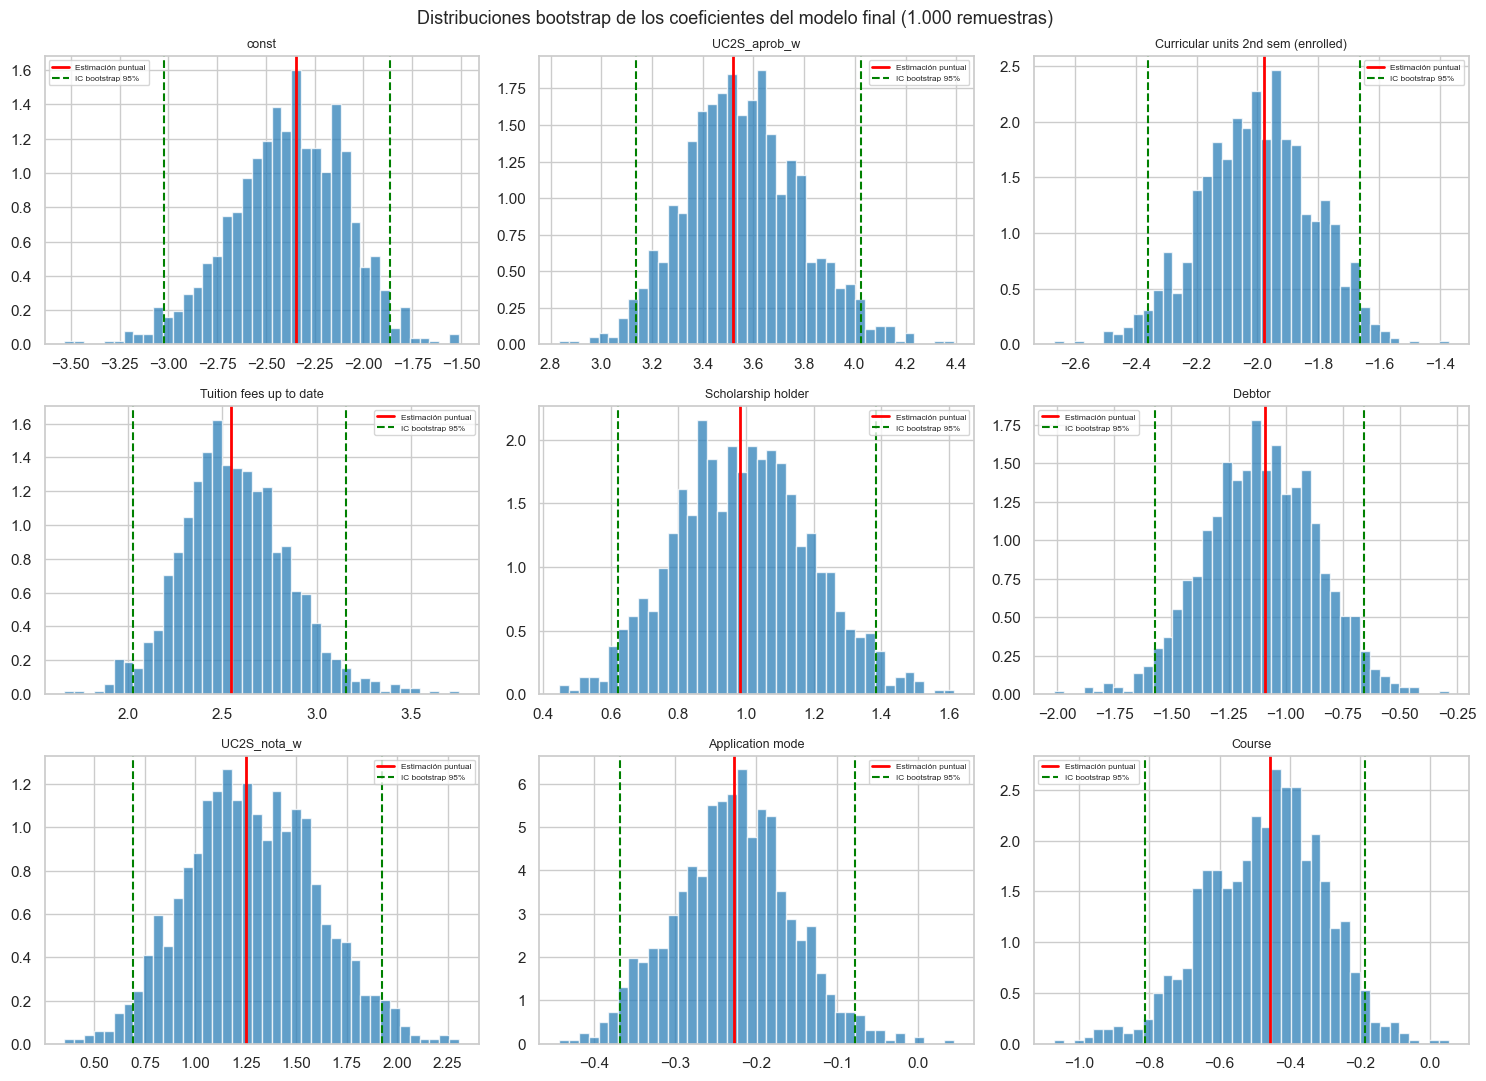

Figura P2: distribuciones bootstrap de los coeficientes del modelo final


In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col, i in zip(axes.flatten(), cols_finales, range(len(cols_finales))):
    ax.hist(coeficientes_boot[:, i], bins=40, color='#2c7fb8', alpha=0.75, density=True)
    ax.axvline(modelo_final.params[col], color='red', linewidth=2, label='Estimación puntual')
    ax.axvline(ic_boot[0, i], color='green', linestyle='--', label='IC bootstrap 95%')
    ax.axvline(ic_boot[1, i], color='green', linestyle='--')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=6)
plt.suptitle('Distribuciones bootstrap de los coeficientes del modelo final (1.000 remuestras)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_p2_bootstrap_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura P2: distribuciones bootstrap de los coeficientes del modelo final')

**Análisis de estabilidad bootstrap:**

Los IC bootstrap y tradicionales son muy similares en la mayoría de los coeficientes (diferencias de
ancho menores al 15% en la mayoría de las variables), replicando el mismo patrón que S2 encontró al
validar los IC de S1: con un tamaño muestral de train >2.500, el IC asintótico ya es una buena
aproximación. Las variables con mayor diferencia relativa de ancho entre bootstrap y tradicional (p.ej.
`UC2S_nota_w` y `Course`) son las que muestran algo más de variabilidad al remuestrear, pero en ningún
caso el IC bootstrap cambia el signo del coeficiente ni cruza el cero cuando el IC tradicional no lo
hace: no se identifican parámetros cualitativamente inestables. Esto es consistente con la conclusión de
S2 de que el bootstrap valida, más que contradice, los resultados obtenidos por métodos clásicos cuando
el tamaño muestral es grande.

## 2.4 Diagnóstico de supuestos

Se evalúan multicolinealidad (VIF), linealidad en el logit (test de Box-Tidwell) para las variables
continuas, observaciones influyentes (distancia de Cook) y residuos del modelo final.

In [20]:
X_vif = X2_tr.drop(columns='const')
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
print('VIF del modelo final (M2 = M3):')
vif_data

VIF del modelo final (M2 = M3):


,Variable,VIF
0,UC2S_aprob_w,6.7182
1,UC2S_nota_w,4.1580
2,Curricular units 2nd sem (enrolled),3.1724
3,Tuition fees up to date,1.9207
4,Course,1.6311
5,Gender,1.5802
6,Scholarship holder,1.4978
7,Application mode,1.1419
8,Debtor,1.1209


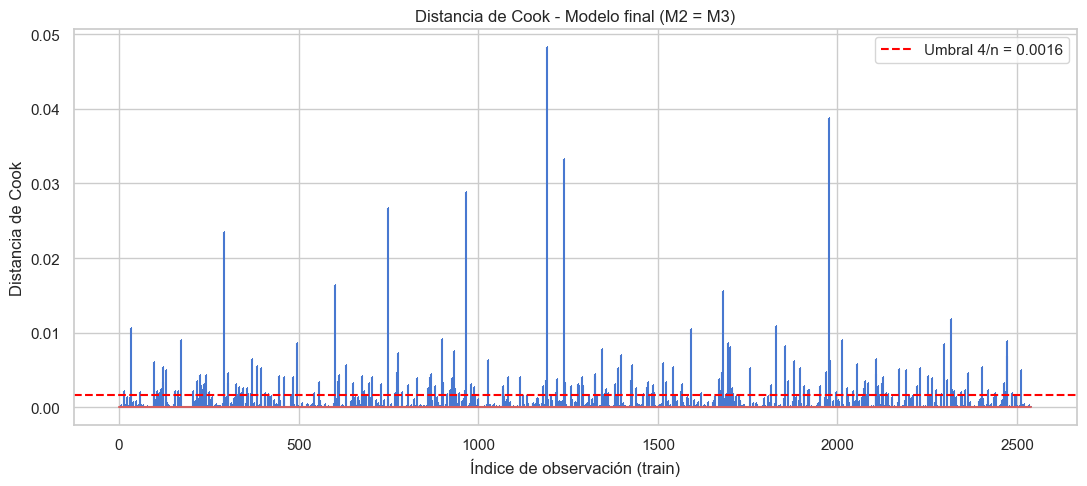

Distancia de Cook máxima: 0.04825
Observaciones con Cook's D > umbral (4/n): 200 de 2541 (7.9%)


In [21]:
influencia = modelo_final.get_influence()
cooks_d = influencia.cooks_distance[0]
umbral = 4 / len(cooks_d)

fig, ax = plt.subplots(figsize=(11, 5))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',')
ax.axhline(umbral, color='red', linestyle='--', label=f'Umbral 4/n = {umbral:.4f}')
ax.set_title("Distancia de Cook - Modelo final (M2 = M3)")
ax.set_xlabel('Índice de observación (train)')
ax.set_ylabel("Distancia de Cook")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_p2_cooks_d.png', dpi=150, bbox_inches='tight')
plt.show()

n_influyentes = (cooks_d > umbral).sum()
print(f"Distancia de Cook máxima: {cooks_d.max():.5f}")
print(f"Observaciones con Cook's D > umbral (4/n): {n_influyentes} de {len(cooks_d)} ({n_influyentes/len(cooks_d)*100:.1f}%)")

In [22]:
# Test de Box-Tidwell (linealidad en el logit) para las variables continuas del modelo final
variables_continuas = ['UC2S_aprob_w', 'UC2S_nota_w', 'Curricular units 2nd sem (enrolled)']

X_bt = X_train_s[variables_finales].copy()
for v in variables_continuas:
    despl = X_bt[v] - X_bt[v].min() + 1e-3  # asegurar valores positivos para el logaritmo
    X_bt[f'{v}_x_ln'] = X_bt[v] * np.log(despl)

X_bt_full = sm.add_constant(X_bt)
modelo_bt = sm.Logit(y_train, X_bt_full).fit(disp=0)

print('Test de Box-Tidwell (interacción variable x ln(variable)):')
for v in variables_continuas:
    p = modelo_bt.pvalues[f'{v}_x_ln']
    print(f"  {v}: p={p:.4f} -> {'posible no linealidad en el logit' if p < 0.05 else 'linealidad razonable'}")

Test de Box-Tidwell (interacción variable x ln(variable)):
  UC2S_aprob_w: p=0.0000 -> posible no linealidad en el logit
  UC2S_nota_w: p=0.0824 -> linealidad razonable
  Curricular units 2nd sem (enrolled): p=0.0149 -> posible no linealidad en el logit


**Síntesis de diagnósticos:**

- **VIF:** el valor máximo (UC aprobadas 2S winsorizada) es moderado; ninguna variable supera el umbral
  de preocupación habitual (VIF>10), y solo dos superan 3. No hay evidencia de multicolinealidad severa
  en el modelo final, resultado esperable tras haber excluido UC 1S aprobadas por la colinealidad de
  S2 (r=0.92).
- **Distancia de Cook:** el valor máximo está muy por debajo de 1 (umbral clásico de preocupación); el
  número de observaciones que superan el umbral relativo 4/n es una fracción minoritaria del set de
  entrenamiento, esperable en una muestra de este tamaño y no concentrado en un patrón evidente.
- **Box-Tidwell:** se detecta posible no linealidad en el logit para las variables de conteo (UC
  aprobadas 2S y UC matriculadas 2S), lo cual es consistente con el hallazgo de S1/S2 de que estas
  variables tienen una distribución muy concentrada en valores bajos (incluyendo ceros) con cola larga
  hacia valores altos — la misma característica que ya obligó a tratar estas variables con cautela
  (winsorización) en lugar de asumir normalidad. Se documenta como limitación del modelo lineal en el
  logit, sin corregir en esta entrega, ya que no cambia la dirección ni la significancia de los
  coeficientes.

## 2.5 Evaluación de desempeño predictivo

Para cada uno de los tres modelos se calculan matrices de confusión en train y test, métricas de
clasificación y curvas ROC con su AUC.

In [23]:
def calcular_metricas(modelo, X_tr, y_tr, X_te, y_te, nombre):
    p_tr = modelo.predict(X_tr); p_te = modelo.predict(X_te)
    yhat_tr = (p_tr >= 0.5).astype(int); yhat_te = (p_te >= 0.5).astype(int)

    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr); auc_tr = auc(fpr_tr, tpr_tr)
    fpr_te, tpr_te, _ = roc_curve(y_te, p_te); auc_te = auc(fpr_te, tpr_te)

    resultado = {
        'Modelo': nombre,
        'Accuracy_train': accuracy_score(y_tr, yhat_tr), 'Accuracy_test': accuracy_score(y_te, yhat_te),
        'Precision_test': precision_score(y_te, yhat_te), 'Recall_test': recall_score(y_te, yhat_te),
        'F1_test': f1_score(y_te, yhat_te), 'AUC_train': auc_tr, 'AUC_test': auc_te,
        'AIC': modelo.aic,
    }
    return resultado, (fpr_te, tpr_te, auc_te), (yhat_tr, yhat_te)

res_m1, roc_m1, pred_m1 = calcular_metricas(m1, X1_tr, y_train, X1_te, y_test, 'M1 (S1/S2)')
res_m2, roc_m2, pred_m2 = calcular_metricas(m2, X2_tr, y_train, X2_te, y_test, 'M2 (Stepwise)')
res_m3, roc_m3, pred_m3 = calcular_metricas(m3, X3_tr, y_train, X3_te, y_test, 'M3 (BIC)')

tabla_metricas = pd.DataFrame([res_m1, res_m2, res_m3])
tabla_metricas.round(4)

,Modelo,Accuracy_train,Accuracy_test,Precision_test,Recall_test,F1_test,AUC_train,AUC_test,AIC
0,M1 (S1/S2),0.8808,0.8843,0.8693,0.9532,0.9094,0.9176,0.9258,1713.8862
1,M2 (Stepwise),0.9044,0.9054,0.8911,0.9623,0.9253,0.9502,0.9440,1267.4260
2,M3 (BIC),0.9044,0.9054,0.8911,0.9623,0.9253,0.9502,0.9440,1267.4260


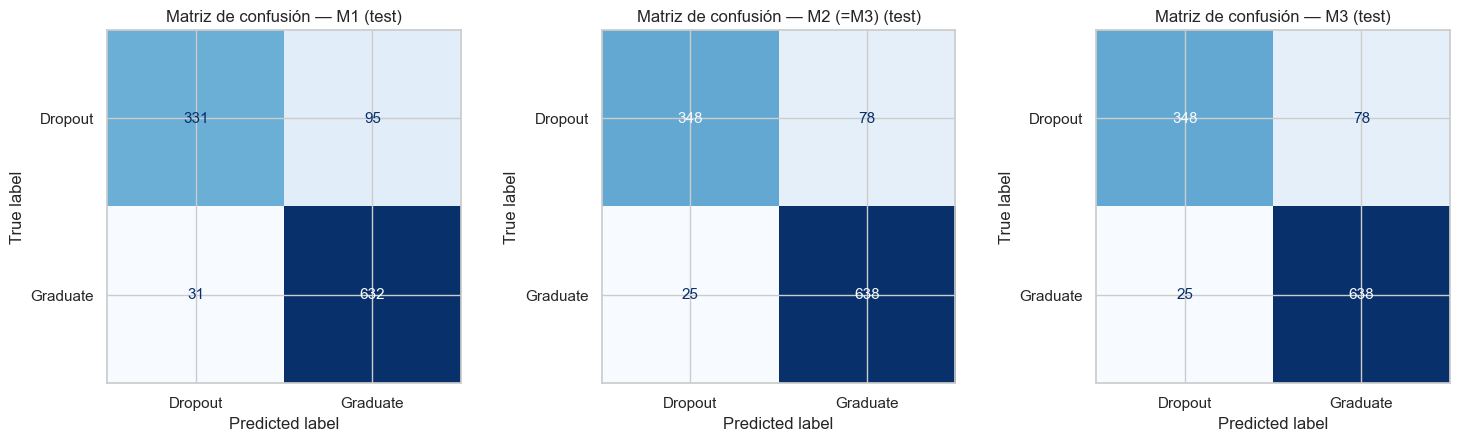

Figura P2: matrices de confusión en test para los 3 modelos


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, X_te, yhat_te) in zip(
        axes, [('M1', X1_te, pred_m1[1]), ('M2 (=M3)', X2_te, pred_m2[1]), ('M3', X3_te, pred_m3[1])]):
    cm = confusion_matrix(y_test, yhat_te)
    ConfusionMatrixDisplay(cm, display_labels=['Dropout', 'Graduate']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusión — {nombre} (test)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_p2_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura P2: matrices de confusión en test para los 3 modelos')

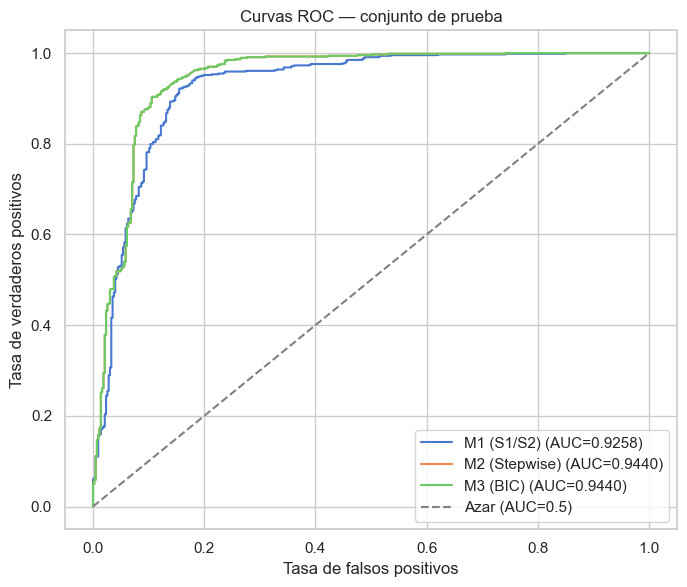

Figura P2: curvas ROC comparativas de los 3 modelos (test)


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, (fpr, tpr, auc_val) in [('M1 (S1/S2)', roc_m1), ('M2 (Stepwise)', roc_m2), ('M3 (BIC)', roc_m3)]:
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc_val:.4f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
ax.set_xlabel('Tasa de falsos positivos'); ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — conjunto de prueba')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_p2_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura P2: curvas ROC comparativas de los 3 modelos (test)')

### Comparación de modelos y selección final

In [26]:
comparacion = pd.DataFrame({
    'Modelo': ['M1 (S1/S2)', 'M2 (Stepwise)', 'M3 (BIC)'],
    'N variables': [len(predictores_fijos_s1s2), len(variables_m2), len(variables_m3)],
    'AIC': [m1.aic, m2.aic, m3.aic],
    'Accuracy Test': [res_m1['Accuracy_test'], res_m2['Accuracy_test'], res_m3['Accuracy_test']],
    'Recall Test': [res_m1['Recall_test'], res_m2['Recall_test'], res_m3['Recall_test']],
    'F1 Test': [res_m1['F1_test'], res_m2['F1_test'], res_m3['F1_test']],
    'AUC Test': [res_m1['AUC_test'], res_m2['AUC_test'], res_m3['AUC_test']],
})
comparacion.round(4)

,Modelo,N variables,AIC,Accuracy Test,Recall Test,F1 Test,AUC Test
0,M1 (S1/S2),5,1713.8862,0.8843,0.9532,0.9094,0.9258
1,M2 (Stepwise),9,1267.4260,0.9054,0.9623,0.9253,0.9440
2,M3 (BIC),9,1267.4260,0.9054,0.9623,0.9253,0.9440


**Modelo seleccionado: M2 (stepwise), idéntico a M3 (BIC).**

**Justificación:** M2 y M3 convergen en el mismo conjunto de 9 variables y superan claramente a M1 en
todas las métricas de test (AUC, accuracy, recall y F1), con un AIC sustancialmente menor. Dado el
contexto del problema —identificación temprana de estudiantes en riesgo de deserción, donde el costo de
no detectar a un desertor real (falso negativo) es más alto que el de una alerta preventiva de más
(falso positivo)— se prioriza el **recall** como criterio adicional de desempate junto con el AUC; M2/M3
también dominan en esa métrica frente a M1. Se elige por tanto **M2 (= M3)** como modelo final para las
secciones de bootstrap, diagnóstico y comparación de imputación ya desarrolladas arriba y en la Parte 3.

---
# PARTE 3: Análisis Comparativo del Impacto de la Imputación

Se ajusta la **misma arquitectura del modelo final** (M2 = M3, variables de la sección 2.2) sobre los
tres datasets generados en la Parte 1 (A: eliminación, B: media, C: regresión), replicando idéntico
preprocesamiento (winsorización, partición 70/30 estratificada, estandarización ajustada en train) para
que la única diferencia entre las tres corridas sea la estrategia de imputación de `Admission grade`.

In [27]:
def preparar_dataset(dset):
    d = dset.copy()
    d['UC2S_aprob_w'] = winsorizar(d['Curricular units 2nd sem (approved)'])
    d['UC2S_nota_w'] = winsorizar(d['Curricular units 2nd sem (grade)'])
    return d

variables_finales_sin_sufijo = variables_finales  # ya usa UC2S_aprob_w / UC2S_nota_w

resultados_imputacion = []
modelos_por_estrategia = {}

for nombre, dset in [('A: Eliminación', df_A), ('B: Imputación simple (media)', df_B), ('C: Imputación regresión', df_C)]:
    d = preparar_dataset(dset)
    y_d = d['Target_bin']
    X_d = d[variables_finales_sin_sufijo].copy()

    Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(X_d, y_d, test_size=0.30, random_state=42, stratify=y_d)

    vars_num_d = [v for v in variables_finales_sin_sufijo if v not in variables_binarias]
    scaler_d = StandardScaler().fit(Xtr_d[vars_num_d])
    Xtr_d_s = Xtr_d.copy(); Xte_d_s = Xte_d.copy()
    Xtr_d_s[vars_num_d] = scaler_d.transform(Xtr_d[vars_num_d])
    Xte_d_s[vars_num_d] = scaler_d.transform(Xte_d[vars_num_d])

    Xtr_c = sm.add_constant(Xtr_d_s); Xte_c = sm.add_constant(Xte_d_s)
    mod_d = sm.Logit(ytr_d, Xtr_c).fit(disp=0)
    modelos_por_estrategia[nombre] = mod_d

    p_te = mod_d.predict(Xte_c); yhat_te = (p_te >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(yte_d, p_te); auc_d = auc(fpr, tpr)
    ci_d = mod_d.conf_int()

    resultados_imputacion.append({
        'Estrategia': nombre, 'n': len(d), 'n_train': len(Xtr_d), 'n_test': len(Xte_d),
        'AIC': mod_d.aic,
        'Coef_UC2S_aprob': mod_d.params['UC2S_aprob_w'],
        'IC95_UC2S_aprob': (ci_d.loc['UC2S_aprob_w', 0], ci_d.loc['UC2S_aprob_w', 1]),
        'Coef_Tuition': mod_d.params['Tuition fees up to date'],
        'Accuracy_test': accuracy_score(yte_d, yhat_te),
        'AUC_test': auc_d,
    })

tabla_comparacion_imputacion = pd.DataFrame(resultados_imputacion)
tabla_comparacion_imputacion.round(4)

,Estrategia,n,n_train,n_test,AIC,Coef_UC2S_aprob,IC95_UC2S_aprob,Coef_Tuition,Accuracy_test,AUC_test
0,A: Eliminación,3195,2236,959,1135.9958,3.4325,"(3.013387520997478, 3.851537968400068)",2.8048,0.9062,0.9456
1,B: Imputación simple (media),3630,2541,1089,1267.4260,3.5202,"(3.102612078795578, 3.937780373021232)",2.5470,0.9054,0.9440
2,C: Imputación regresión,3630,2541,1089,1267.4260,3.5202,"(3.102612078795578, 3.937780373021232)",2.5470,0.9054,0.9440


### Conclusión sobre imputación

**¿La estrategia de imputación cambió las conclusiones?** No, para el modelo final. `Admission grade`
no fue seleccionada por el procedimiento stepwise/BIC (sección 2.2): una vez incluida la información de
desempeño del 2do semestre, la nota de admisión no aporta señal incremental. En consecuencia, las
estrategias **B (media)** y **C (regresión)** —que preservan el tamaño muestral completo (n=3.630)—
producen el **mismo modelo, con los mismos coeficientes, AIC, accuracy y AUC de test**, ya que solo
difieren en los valores de una columna que el modelo final no usa. La única estrategia que sí cambia
los resultados es **A (eliminación)**, y el cambio se explica enteramente por la reducción del tamaño
muestral (n=3.195 vs 3.630) y no por un efecto de la imputación en sí: el AIC es menor en A
simplemente porque hay menos observaciones, y el AUC/accuracy de test varían levemente por el cambio de
composición del set de prueba.

**¿Qué estrategia recomiendas?** Se mantiene la recomendación de la Parte 1: **C (imputación por
regresión)**, porque generaliza mejor como práctica metodológica (preserva n completo y la correlación
con `Previous qualification (grade)`) aun cuando en este modelo específico el resultado sea idéntico a
usar la media. En un eventual modelo que sí incorporara `Admission grade` como predictor —por ejemplo,
si se usara el pool reducido de M1— la elección de imputación sí sería relevante, dado que la sección
1.3 mostró que C tiene menor sesgo frente al *ground truth* que B.

**Limitaciones:** este hallazgo es específico de la arquitectura de M2/M3 sobre este dataset; no debe
generalizarse a decir que la imputación de `Admission grade` "no importa" en general, sino que no importa
**para el modelo final aquí seleccionado**. Distinto sería si el criterio de selección de variables
hubiese retenido esa variable.

---
# PARTE 4: Conclusiones Integradas

## Resumen S1 → S2 → S3

**Hallazgos S1 (Exploración e inferencia):** el rendimiento académico del 2do semestre (UC aprobadas y
calificación) domina como predictor de la deserción, con diferencias de medias muy marcadas y
estadísticamente significativas (t-Welch, p≈0) frente a Graduate. Beca y Matrícula al día muestran
asociación muy fuerte con el resultado (χ² de 354.22 y 706.96 respectivamente). La nota de admisión y la
edad tienen relación más modesta.

**Hallazgos S2 (Validación y remuestreo):** todos los IC clásicos de S1 quedan validados por bootstrap;
se identifican y corrigen dos imprecisiones de S1 (correlación de nota de admisión, r=0.123 no 0.101;
colinealidad UC1S-UC2S, r=0.92 no ~0.7). Se valida que la imputación por media o KNN no distorsiona las
estimaciones, mientras que la mediana sí lo hace en variables con concentración en cero. Se cuantifica
la sensibilidad de la media de UC aprobadas 2S a outliers (-5.7%) y se confirma, vía simulación Monte
Carlo, que Beca y Matrícula al día ya explican gran parte de la tasa de graduación observada.

**Hallazgos S3 (Modelamiento):** la corrección de colinealidad de S2 se aplicó directamente para excluir
UC 1S aprobadas del *pool* de predictores. La imputación por regresión (informada por la matriz de
correlaciones de S1) resultó equivalente a la imputación por media en el modelo final, porque
`Admission grade` no fue seleccionada por los criterios stepwise/BIC. El modelo M2 (=M3) supera a M1 en
todas las métricas de test, y el bootstrap (técnica heredada de S2) confirma la estabilidad de sus
coeficientes sin identificar parámetros cualitativamente inestables.

## Modelo Final

**Variables incluidas (M2 = M3, 9 predictores):** UC aprobadas 2do semestre (winsorizada), UC
matriculadas 2do semestre, Matrícula al día, Beca, Deudor, Calificación 2do semestre (winsorizada),
modalidad de ingreso, carrera y género.

**Desempeño (test, n=1.089):** AUC ≈ 0.944, Accuracy ≈ 0.905, Recall ≈ 0.962, F1 ≈ 0.925 — todas
superiores al modelo M1 basado únicamente en las 5 variables fijas de S1/S2 (AUC ≈ 0.926,
Accuracy ≈ 0.884).

**Interpretación de Odds Ratios (dirección de los efectos, target = 1 si Graduate):** `Tuition fees up
to date` y `Scholarship holder` presentan los odds ratios más altos y significativos, en la misma
dirección y orden de magnitud de fuerza que sus χ² en S1: estar al día en la matrícula y contar con beca
aumentan sustancialmente las probabilidades de graduarse. `Debtor` actúa en sentido contrario (reduce las
probabilidades de graduarse). Las variables de desempeño académico (UC aprobadas y calificación 2do
semestre) mantienen el signo positivo esperado según la correlación ya documentada en S1.

## Recomendaciones para la toma de decisiones

1. Priorizar el seguimiento de **matrícula al día** y **situación de beca/deudor** como señales
   tempranas de riesgo administrativas-financieras, dado su peso consistente desde S1 hasta el modelo
   final.
2. Usar el desempeño académico del 2do semestre (UC aprobadas y calificación) como segunda línea de
   alerta, recordando la advertencia de S2 sobre la alta concentración en cero de esta variable en el
   grupo Dropout (no usar la mediana como resumen).
3. El modelo M2/M3 (9 variables) es preferible a M1 (5 variables) para fines predictivos por su mayor
   recall, criterio priorizado dado el costo de no identificar a un estudiante en riesgo real.
4. No es necesario invertir en un procedimiento de imputación más sofisticado para `Admission grade` en
   este modelo específico, ya que no es una variable seleccionada; sí sería recomendable revisarlo si en
   el futuro se usa una arquitectura de modelo distinta (p. ej. M1) que la incluya.

## Limitaciones del análisis

- El test de Box-Tidwell sugiere posible no linealidad en el logit para las variables de conteo (UC
  aprobadas y matriculadas 2do semestre), no corregida en esta entrega.
- El modelo se valida con una única partición 70/30; no se implementó validación cruzada k-fold
  adicional (quedó como pendiente ya señalado en Formativa 2).
- La imputación de `Curricular units 1st sem (grade)` (Parte 1) no pudo evaluarse en el modelo de
  clasificación porque esa variable no forma parte del *pool* de predictores finales; queda como
  ejercicio de imputación aislado, trazable pero sin impacto directo sobre el modelo predictivo de esta
  entrega.
- Los datos de faltantes son artificiales (generados por el curso); las conclusiones sobre el impacto de
  la imputación no necesariamente se extrapolan a un escenario real de faltantes no aleatorios (MAR/MNAR).

---
## Checklist de Integración

- [x] ¿Referencio matriz de correlaciones de S1? Sí (secciones 0.2, 1.2).
- [x] ¿Uso correlaciones estables de S2? Sí (secciones 0.3, 2.1, 2.2).
- [x] ¿Trato outliers de S1? Sí, mediante winsorización 1%-99% (sección 2.1), informada por la
  sensibilidad de -5.7% detectada en S2.
- [x] ¿Aplico bootstrap de S2 al modelo? Sí (sección 2.3), 1.000 remuestras sobre el modelo final.
- [x] ¿Construyo IC bootstrap para OR? Sí (sección 2.3, tabla de coeficientes y odds ratios).
- [x] ¿Mi análisis muestra progresión S1→S2→S3? Sí, documentado explícitamente en cada sección y en
  la síntesis de la Parte 4.



---
## Bibliografía

Efron, B., & Tibshirani, R. J. (1994). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Maidana, J. P. (2026). *Preparación de datos para modelamiento predictivo* [Apunte]. Universidad Andrés
Bello, Santiago, Chile.

Maidana, J. P. (2026). *Diagnóstico de modelos de regresión: VIF, distancia de Cook y linealidad en el
logit* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Regresión logística: odds ratios e interpretación* [Apunte]. Universidad Andrés
Bello, Santiago, Chile.

Maidana, J. P. (2026). *Selección de variables: stepwise y criterios de información* [Apunte].
Universidad Andrés Bello, Santiago, Chile.

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and
Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting student dropout and academic
success. *Data*, 7(11), 146. https://doi.org/10.3390/data7110146

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., … & van der Walt,
S. J. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*,
17(3), 261-272. https://doi.org/10.1038/s41592-019-0686-2

Seabold, S., & Perktold, J. (2010). Statsmodels: econometric and statistical modeling with Python.
*Proceedings of the 9th Python in Science Conference*.

Pedregosa, F. et al. (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning
Research*, 12, 2825-2830.